# Section 12: More on data

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

from scipy import stats
import io
import requests
import copy

## Anatomy of a torch dataset and dataloader

In [2]:
n_observations = 100
n_features = 20

data = np.random.randn(n_observations, n_features)

In [3]:
data_t = torch.tensor(data)

print("Numpy data:")
print(type(data))
print(data.shape)
print(data.dtype)
print()
print("Tensor data:")
print(type(data_t))
print(data_t.shape)
print(data_t.dtype)

Numpy data:
<class 'numpy.ndarray'>
(100, 20)
float64

Tensor data:
<class 'torch.Tensor'>
torch.Size([100, 20])
torch.float64


In [4]:
data_t2 = torch.tensor(data).float()
print(data_t2.dtype)

data_t3 = torch.tensor(data).long()
print(data_t3.dtype)

torch.float32
torch.int64


In [5]:
data

array([[-0.99620468,  0.10403341,  1.29282048, ...,  0.57250225,
        -0.66895902,  1.15006084],
       [-0.91123706,  2.03868212,  0.27771917, ..., -0.29014331,
        -0.26681799, -1.18895264],
       [-0.58467152, -1.71684766, -0.24019449, ...,  1.01703363,
        -0.14980749, -1.24483211],
       ...,
       [ 1.14929292,  0.03490118, -1.64377922, ..., -0.16189136,
         1.40013135, -0.86795579],
       [ 1.18766248,  2.28281945,  1.20866031, ...,  0.96883305,
         1.00708591, -0.85091399],
       [-0.61279279, -0.61196172,  2.75526787, ..., -1.07284945,
        -0.97292816, -0.36726846]], shape=(100, 20))

In [6]:
data_t

tensor([[-0.9962,  0.1040,  1.2928,  ...,  0.5725, -0.6690,  1.1501],
        [-0.9112,  2.0387,  0.2777,  ..., -0.2901, -0.2668, -1.1890],
        [-0.5847, -1.7168, -0.2402,  ...,  1.0170, -0.1498, -1.2448],
        ...,
        [ 1.1493,  0.0349, -1.6438,  ..., -0.1619,  1.4001, -0.8680],
        [ 1.1877,  2.2828,  1.2087,  ...,  0.9688,  1.0071, -0.8509],
        [-0.6128, -0.6120,  2.7553,  ..., -1.0728, -0.9729, -0.3673]],
       dtype=torch.float64)

In [7]:
data_t2

tensor([[-0.9962,  0.1040,  1.2928,  ...,  0.5725, -0.6690,  1.1501],
        [-0.9112,  2.0387,  0.2777,  ..., -0.2901, -0.2668, -1.1890],
        [-0.5847, -1.7168, -0.2402,  ...,  1.0170, -0.1498, -1.2448],
        ...,
        [ 1.1493,  0.0349, -1.6438,  ..., -0.1619,  1.4001, -0.8680],
        [ 1.1877,  2.2828,  1.2087,  ...,  0.9688,  1.0071, -0.8509],
        [-0.6128, -0.6120,  2.7553,  ..., -1.0728, -0.9729, -0.3673]])

In [8]:
data_t3

tensor([[ 0,  0,  1,  ...,  0,  0,  1],
        [ 0,  2,  0,  ...,  0,  0, -1],
        [ 0, -1,  0,  ...,  1,  0, -1],
        ...,
        [ 1,  0, -1,  ...,  0,  1,  0],
        [ 1,  2,  1,  ...,  0,  1,  0],
        [ 0,  0,  2,  ..., -1,  0,  0]])

In [9]:
dataset = TensorDataset(data_t)

dataset.tensors

(tensor([[-0.9962,  0.1040,  1.2928,  ...,  0.5725, -0.6690,  1.1501],
         [-0.9112,  2.0387,  0.2777,  ..., -0.2901, -0.2668, -1.1890],
         [-0.5847, -1.7168, -0.2402,  ...,  1.0170, -0.1498, -1.2448],
         ...,
         [ 1.1493,  0.0349, -1.6438,  ..., -0.1619,  1.4001, -0.8680],
         [ 1.1877,  2.2828,  1.2087,  ...,  0.9688,  1.0071, -0.8509],
         [-0.6128, -0.6120,  2.7553,  ..., -1.0728, -0.9729, -0.3673]],
        dtype=torch.float64),)

In [10]:
len(dataset.tensors)

1

In [11]:
labels = torch.ceil(torch.linspace(.01, 4, n_observations))
labels = labels.reshape((len(labels), 1))
dataset = TensorDataset(data_t, labels)

print(dataset.tensors[0])
print(dataset.tensors[1])
print(np.shape(np.random.randint(5, size=n_observations)))

tensor([[-0.9962,  0.1040,  1.2928,  ...,  0.5725, -0.6690,  1.1501],
        [-0.9112,  2.0387,  0.2777,  ..., -0.2901, -0.2668, -1.1890],
        [-0.5847, -1.7168, -0.2402,  ...,  1.0170, -0.1498, -1.2448],
        ...,
        [ 1.1493,  0.0349, -1.6438,  ..., -0.1619,  1.4001, -0.8680],
        [ 1.1877,  2.2828,  1.2087,  ...,  0.9688,  1.0071, -0.8509],
        [-0.6128, -0.6120,  2.7553,  ..., -1.0728, -0.9729, -0.3673]],
       dtype=torch.float64)
tensor([[1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [2.],
        [2.],
        [2.],
        [2.],
        [2.],
        [2.],
        [2.],
        [2.],
        [2.],
        [2.],
        [2.],
        [2.],
        [2.],
      

In [12]:
batch_size = 25
data_loader = DataLoader(dataset, batch_size=batch_size)

data_loader.dataset.tensors[0].size()

torch.Size([100, 20])

In [13]:
for dat, lab in data_loader:
    print("BATCH INFO:")
    print(dat.size())
    print(lab.size())
    print(' ')

BATCH INFO:
torch.Size([25, 20])
torch.Size([25, 1])
 
BATCH INFO:
torch.Size([25, 20])
torch.Size([25, 1])
 
BATCH INFO:
torch.Size([25, 20])
torch.Size([25, 1])
 
BATCH INFO:
torch.Size([25, 20])
torch.Size([25, 1])
 


In [14]:
for dat, lab in data_loader:
    print(lab.T)
    print(' ')

tensor([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
         1., 1., 1., 1., 1., 1., 1.]])
 
tensor([[2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
         2., 2., 2., 2., 2., 2., 2.]])
 
tensor([[3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3.,
         3., 3., 3., 3., 3., 3., 3.]])
 
tensor([[4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4.,
         4., 4., 4., 4., 4., 4., 4.]])
 


In [15]:
data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

for dat, lab in data_loader:
    print(lab.T)
    print(' ')

tensor([[1., 1., 3., 4., 4., 1., 4., 2., 2., 4., 3., 4., 2., 3., 2., 1., 4., 1.,
         2., 3., 4., 3., 4., 4., 4.]])
 
tensor([[1., 3., 2., 3., 3., 1., 3., 3., 4., 2., 3., 2., 1., 2., 2., 2., 1., 1.,
         2., 4., 2., 1., 1., 3., 1.]])
 
tensor([[2., 3., 4., 4., 4., 4., 2., 4., 4., 4., 2., 2., 3., 3., 3., 1., 1., 1.,
         4., 3., 1., 1., 2., 4., 2.]])
 
tensor([[3., 3., 3., 1., 3., 4., 3., 4., 1., 3., 2., 2., 2., 3., 1., 1., 3., 2.,
         4., 1., 2., 1., 2., 4., 1.]])
 


In [16]:
dat, lab = next(iter(data_loader))

print(dat)
print(lab)

tensor([[-1.5766e+00, -4.3388e-02,  2.8731e-01,  6.0762e-01, -1.0770e+00,
         -1.4019e-01, -1.7722e-01,  1.2127e+00,  1.3661e+00,  6.5161e-01,
          4.4624e-01, -1.3667e+00,  5.4993e-01,  6.6654e-01, -1.7378e-01,
          3.2551e-01, -3.1493e-01,  2.6085e-01, -1.0894e+00, -1.0604e+00],
        [-3.0941e-01,  6.8597e-01,  1.3660e-01, -6.0803e-02,  8.0367e-01,
         -1.9909e-01,  4.0546e-01, -7.0937e-01, -8.1521e-01,  6.8277e-01,
          1.5701e-01,  7.8246e-01, -3.4981e-03,  6.0676e-01,  1.0287e+00,
          2.3091e-01,  7.7084e-01,  5.3262e-01,  7.0766e-01, -8.0455e-01],
        [ 5.5244e-01, -2.2827e-01,  1.7826e+00, -2.3289e-01,  6.4182e-01,
         -3.4841e-02,  1.5961e-01, -1.1873e-01,  3.0432e-01, -5.0397e-01,
         -4.1443e-01,  8.3463e-01, -6.5185e-01,  6.0478e-01,  2.0829e-01,
          1.3653e+00, -7.1759e-01, -6.2639e-01,  3.9067e-01,  7.1947e-01],
        [-4.0741e-01,  1.1365e+00,  5.9758e-01,  9.5462e-01,  6.8931e-01,
          4.3067e-02, -1.2181e+00, 

## Data size and network size

In [17]:
def create_data(n_per_clust):
    A = [1, 1]
    B = [5, 1]
    C = [4, 4]
    
    a = [A[0] + np.random.randn(n_per_clust), A[1] + np.random.randn(n_per_clust)]
    b = [B[0] + np.random.randn(n_per_clust), B[1] + np.random.randn(n_per_clust)]
    c = [C[0] + np.random.randn(n_per_clust), C[1] + np.random.randn(n_per_clust)]
    
    data_np = np.hstack((a, b, c)).T
    labels_np = np.hstack((np.zeros(n_per_clust), np.ones(n_per_clust), 1 + np.ones(n_per_clust)))
    
    output = {
        'data': torch.tensor(data_np).float(),
        'labels': torch.tensor(labels_np).long(),
    }
    
    train_data_local, test_data_local, train_labels, test_labels = train_test_split(output['data'], output['labels'], train_size=.9)
    
    train_data_local = TensorDataset(train_data_local, train_labels)
    test_data_local = TensorDataset(test_data_local, test_labels)
    
    batch_size_local = 8
    output['train_data'] = DataLoader(train_data_local, batch_size=batch_size_local, shuffle=True, drop_last=True)
    output['test_data'] = DataLoader(test_data_local, batch_size=test_data_local.tensors[0].shape[0])
    
    return output

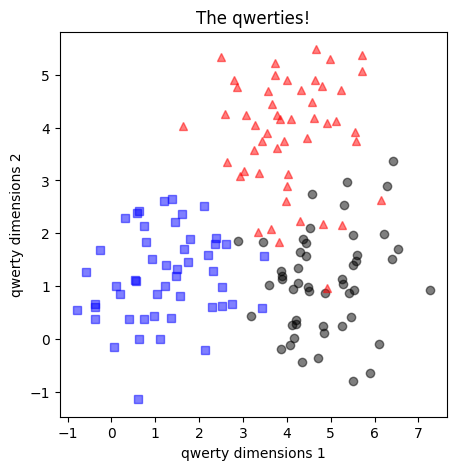

In [18]:
the_data = create_data(50)

data = the_data['data']
labels = the_data['labels']
fig = plt.figure(figsize=(5, 5))

plt.plot(data[np.where(labels==0)[0], 0], data[np.where(labels==0)[0], 1], 'bs', alpha=.5)
plt.plot(data[np.where(labels==1)[0], 0], data[np.where(labels==1)[0], 1], 'ko', alpha=.5)
plt.plot(data[np.where(labels==2)[0], 0], data[np.where(labels==2)[0], 1], 'r^', alpha=.5)
plt.title("The qwerties!")
plt.xlabel("qwerty dimensions 1")
plt.ylabel("qwerty dimensions 2")
plt.show()

In [19]:
def create_qwerty_model(n_units_param, n_layers_param):
    class QwertyNet(nn.Module):
        def __init__(self):
            super().__init__()
            
            self.layers = nn.ModuleDict()
            self.n_layers = n_layers_param
            
            self.layers['input'] = nn.Linear(2, n_units_param)
            
            for i in range(n_layers_param):
                self.layers[f'hidden{i}'] = nn.Linear(n_units_param, n_units_param)
                
            self.layers['output'] = nn.Linear(n_units_param, 3)
            
        def forward(self, x):
            x = self.layers['input'](x)
            
            for i in range(self.n_layers):
                x = F.relu(self.layers[f'hidden{i}'](x))
                
            x = self.layers['output'](x)
            
            return x
        
    net_local = QwertyNet()
    loss_fun_local = nn.CrossEntropyLoss()
    opt_local = torch.optim.SGD(net_local.parameters(), lr=.01)
    
    return net_local, loss_fun_local, opt_local

In [20]:
n_units = 12
n_layers = 4

net, loss_fun, opt = create_qwerty_model(n_units, n_layers)

net(torch.rand(10, 2))

tensor([[ 0.1150, -0.2080, -0.1049],
        [ 0.1164, -0.2054, -0.1041],
        [ 0.1165, -0.2048, -0.1039],
        [ 0.1148, -0.2082, -0.1043],
        [ 0.1158, -0.2064, -0.1043],
        [ 0.1153, -0.2073, -0.1047],
        [ 0.1165, -0.2045, -0.1039],
        [ 0.1153, -0.2067, -0.1044],
        [ 0.1154, -0.2072, -0.1040],
        [ 0.1164, -0.2051, -0.1040]], grad_fn=<AddmmBackward0>)

In [21]:
def train_model(n_units_param, n_layers_param, train_data_param, test_data_param):
    num_epochs = 50
    net_local, loss_fun_local, opt_local = create_qwerty_model(n_units_param, n_layers_param)
    losses_local = torch.zeros(num_epochs)
    train_acc_local = []
    test_acc_local = []
    
    for epoch_i in range(num_epochs):
        batch_acc = []
        batch_loss = []
        
        for X_local, y_local in train_data_param:
            y_pred = net_local(X_local)
            loss = loss_fun_local(y_pred, y_local)
            
            opt_local.zero_grad()
            loss.backward()
            opt_local.step()
            
            batch_loss.append(loss.item())
            
            matches = torch.argmax(y_pred, axis=1) == y_local
            matches_numeric = matches.float()
            accuracy_per = 100 * torch.mean(matches_numeric)
            batch_acc.append(accuracy_per)
            
        train_acc_local.append(np.mean(batch_acc))
        
        losses_local[epoch_i] = np.mean(batch_loss)
        
        X, y = next(iter(test_data_param))
        
        with torch.no_grad():
            y_pred = net_local(X)
            
        test_acc_local.append(100 * torch.mean((torch.argmax(y_pred, axis=1) == y).float()))
        
    return train_acc_local, test_acc_local, losses_local, net_local

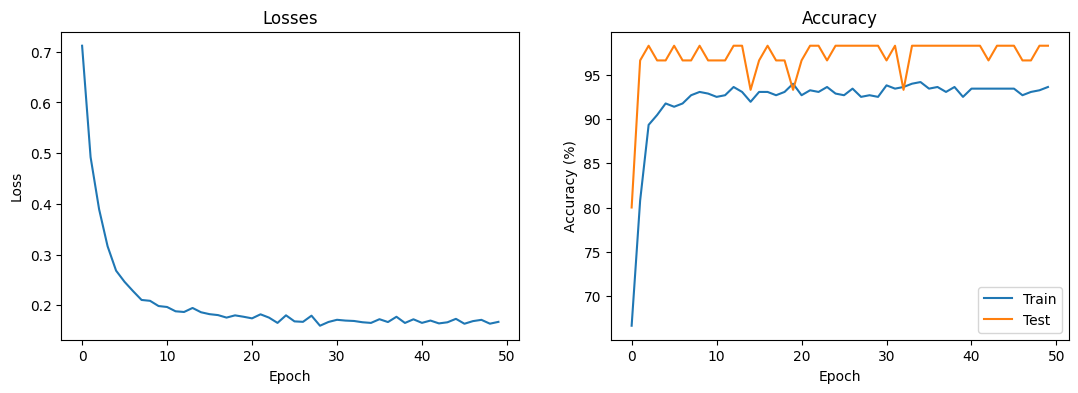

In [22]:
the_data = create_data(200)
train_data = the_data['train_data']
test_data = the_data['test_data']
train_acc, test_acc, losses, net = train_model(80, 1, train_data, test_data)
_, ax = plt.subplots(1, 2, figsize=(13, 4))

ax[0].plot(losses.detach())
ax[0].set_ylabel('Loss')
ax[0].set_xlabel('Epoch')
ax[0].set_title('Losses')

ax[1].plot(train_acc, label='Train')
ax[1].plot(test_acc, label='Test')
ax[1].set_ylabel("Accuracy (%)")
ax[1].set_xlabel('Epoch')
ax[1].set_title('Accuracy')
ax[1].legend()
plt.show()

In [23]:
n_nodes_in_model = 80
layers_range = [1, 5, 10, 20]
n_data_points = np.arange(50, 551, 50)

legend = []

for l_idx, layers in enumerate(layers_range):
    units_per_layer = int(n_nodes_in_model / layers_range[l_idx])
    net = create_qwerty_model(units_per_layer, layers)[0]
    
    n_params = np.sum([p.numel() for p in net.parameters() if p.requires_grad])
    
    legend.append("%s layer, %s units, %s params" %(layers, units_per_layer, n_params))
    
    print("This model will have %s layers, each with %s units, totalling %s parameters" %(layers, units_per_layer, n_params))

This model will have 1 layers, each with 80 units, totalling 6963 parameters
This model will have 5 layers, each with 16 units, totalling 1459 parameters
This model will have 10 layers, each with 8 units, totalling 771 parameters
This model will have 20 layers, each with 4 units, totalling 427 parameters


In [24]:
results = np.zeros((len(n_data_points), len(layers_range), 2))

for d_idx, points in enumerate(n_data_points):
    the_data = create_data(points)
    train_data = the_data['train_data']
    test_data = the_data['test_data']
    
    for l_idx, layers in enumerate(layers_range):
        units_per_layer = int(n_nodes_in_model / layers_range[l_idx])
        train_acc, test_acc, losses, net = train_model(units_per_layer, layers, train_data, test_data)
        results[d_idx, l_idx, 0] = np.mean(test_acc[-5:])
        results[d_idx, l_idx, 1] = torch.mean(losses[-5:]).item()

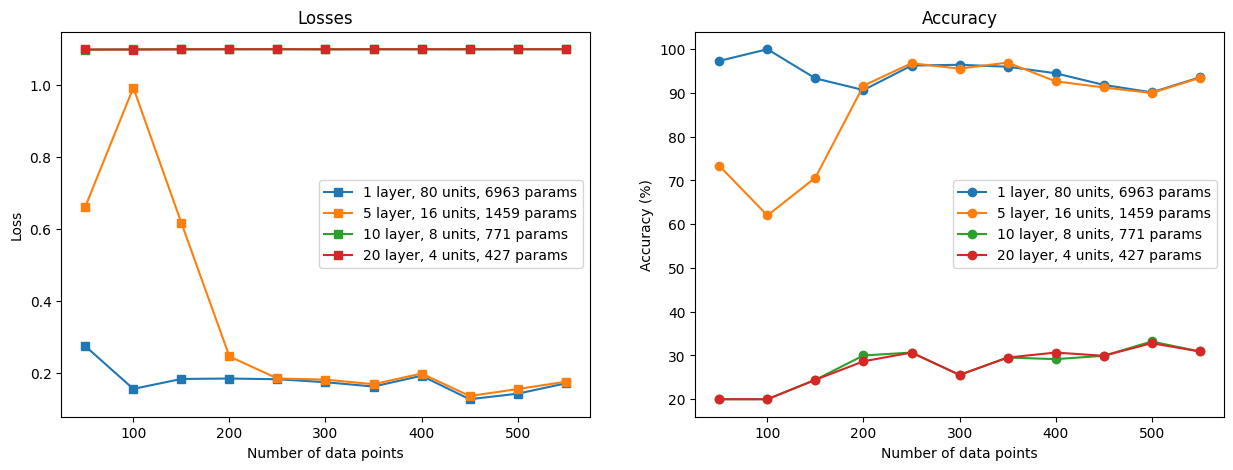

In [25]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].plot(n_data_points, results[:, :, 1], 's-')
ax[0].set_ylabel('Loss')
ax[0].set_xlabel("Number of data points")
ax[0].legend(legend)
ax[0].set_title('Losses')

ax[1].plot(n_data_points, results[:, :, 0], 'o-')
ax[1].set_ylabel("Accuracy (%)")
ax[1].set_xlabel("Number of data points")
ax[1].set_title('Accuracy')
ax[1].legend(legend)
plt.show()

## CodeChallenge: unbalanced data

In [26]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
r = requests.get(url, timeout=30)

r.raise_for_status()

data = pd.read_csv(io.StringIO(r.text), sep=';')
data = data[data["total sulfur dioxide"] < 200]

In [27]:
def get_train_test_dataloaders(data_param, threshold):
    data_local = data_param.copy()
    columns_to_z_score = data_local.keys()
    columns_to_z_score = columns_to_z_score.drop('quality')
    
    data_local['bool_quality'] = 0
    data_local.loc[data_local['quality'] > threshold, 'bool_quality'] = 1
    
    X = torch.tensor(data_local[columns_to_z_score].values).float()
    y = torch.tensor(data_local['bool_quality'].values).float()
    y = y[:, None]
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.1)
    
    X_y_train = TensorDataset(X_train, y_train)
    X_y_test = TensorDataset(X_test, y_test)
    
    batch_size_local = 32
    train_loader = DataLoader(X_y_train, batch_size=batch_size_local, shuffle=True, drop_last=True)
    test_loader = DataLoader(X_y_test, batch_size=X_y_test.tensors[0].shape[0])
    
    return train_loader, test_loader

In [28]:
class AnnWine(nn.Module):
    def __init__(self, activation_function_param):
        super().__init__()
        
        self.input = nn.Linear(11, 16)
        self.fully_connected_1 = nn.Linear(16, 32)
        self.fully_connected_2 = nn.Linear(32, 32)
        self.output = nn.Linear(32, 1)
        self.activation_function = activation_function_param
        
    def forward(self, x_param):
        activation_function_local = getattr(torch.nn, self.activation_function)
        
        x_local = self.input(x_param)
        x_local = activation_function_local()(x_local)
        x_local = self.fully_connected_1(x_local)
        x_local = activation_function_local()(x_local)
        x_local = self.fully_connected_2(x_local)
        x_local = activation_function_local()(x_local)
        x_local = self.output(x_local)
        
        return x_local

In [29]:
def train_model(model_param, epochs_param, train_loader_param, test_loader_param):
     loss_fun_local = nn.BCEWithLogitsLoss()
     optimizer_local = torch.optim.Adam(model_param.parameters(), lr=.001)
     
     train_accuracies_local = []
     test_accuracies_local = []
     losses_local = []
     
     for epoch in range(epochs_param):
          batch_accuracies = []
          batch_losses = []
         
          model_param.train()
         
          for X_local, y_local in train_loader_param:
               y_pred = model_param(X_local)
               loss = loss_fun_local(y_pred, y_local)
               
               optimizer_local.zero_grad()
               loss.backward()
               optimizer_local.step()
             
               correct_predictions = ((y_pred > 0) == y_local).float()
             
               batch_accuracies.append(100 * torch.mean(correct_predictions).item())
               batch_losses.append(loss.item())
             
          train_accuracies_local.append(np.mean(batch_accuracies))
          losses_local.append(np.mean(batch_losses))
    
          model_param.eval()
          
          X_local, y_local = next(iter(test_loader_param))
          
          with torch.no_grad():
               y_pred = model_param(X_local)
          
          correct_predictions = ((y_pred > 0) == y_local).float()
          
          test_accuracies_local.append(100 * torch.mean(correct_predictions).item())
     
     return train_accuracies_local, test_accuracies_local, losses_local

In [30]:
def train_model_and_plot_results(train_loader_param, test_loader_param):
    activation_functions = ['LeakyReLU']
    epochs = 500
    
    train_accuracies = np.zeros((epochs, len(activation_functions)))
    test_accuracies = np.zeros((epochs, len(activation_functions)))
    
    for i, activation_function in enumerate(activation_functions):
        ann_wine = AnnWine(activation_function)
        train_accuracies[:, i], test_accuracies[:, i], _ = train_model(ann_wine, epochs, train_loader_param, test_loader_param) 
        
    _, ax_local = plt.subplots(1, 2, figsize=(20, 7))
    
    ax_local[0].plot(train_accuracies)
    ax_local[0].set_title("Train accuracy")
    ax_local[1].plot(test_accuracies)
    ax_local[1].set_title("Test accuracy")
    
    for i in range(2):
        ax_local[i].legend(activation_functions)
        ax_local[i].set_xlabel('Epoch')
        ax_local[i].set_ylabel("Accuracy (%)")
        ax_local[i].set_ylim([50, 100])
        ax_local[i].grid()
        
    plt.show()

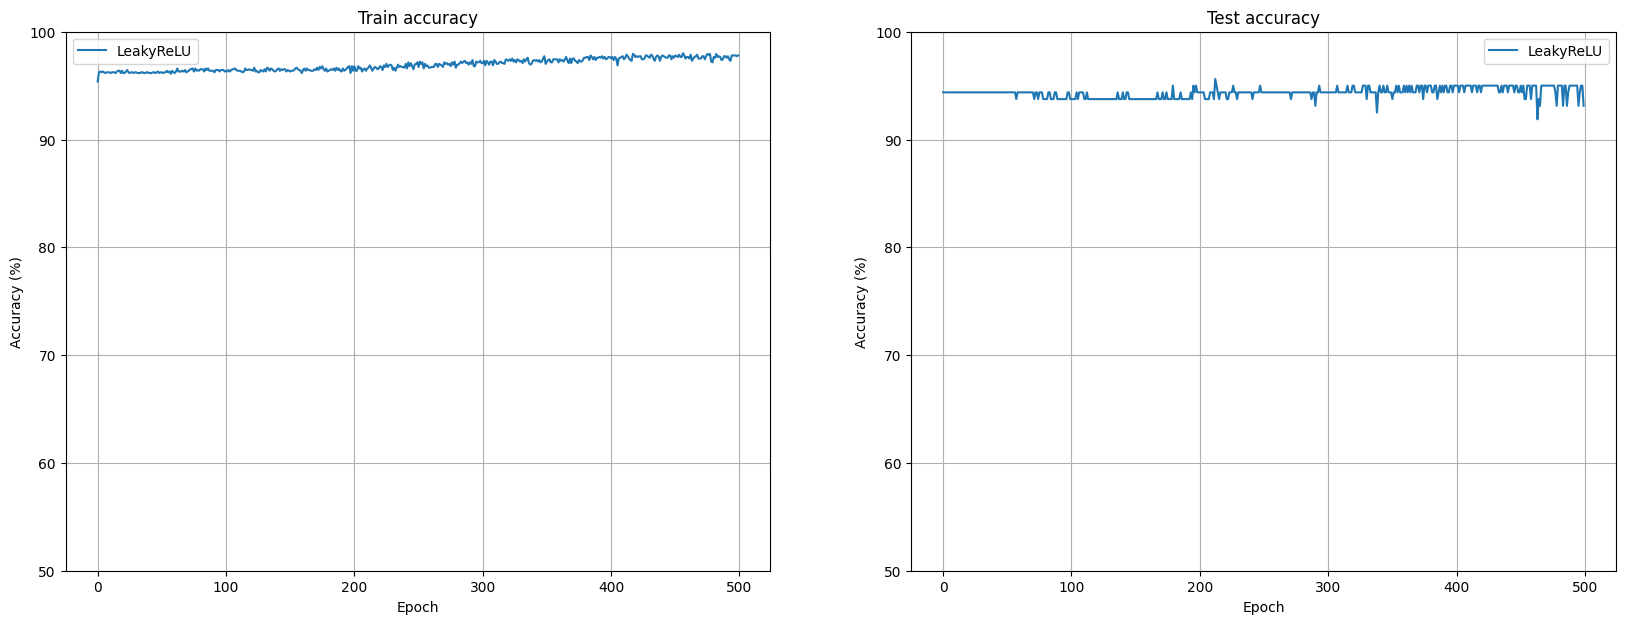

In [31]:
train_loader, test_loader = get_train_test_dataloaders(data, 4.5)
train_model_and_plot_results(train_loader, test_loader)

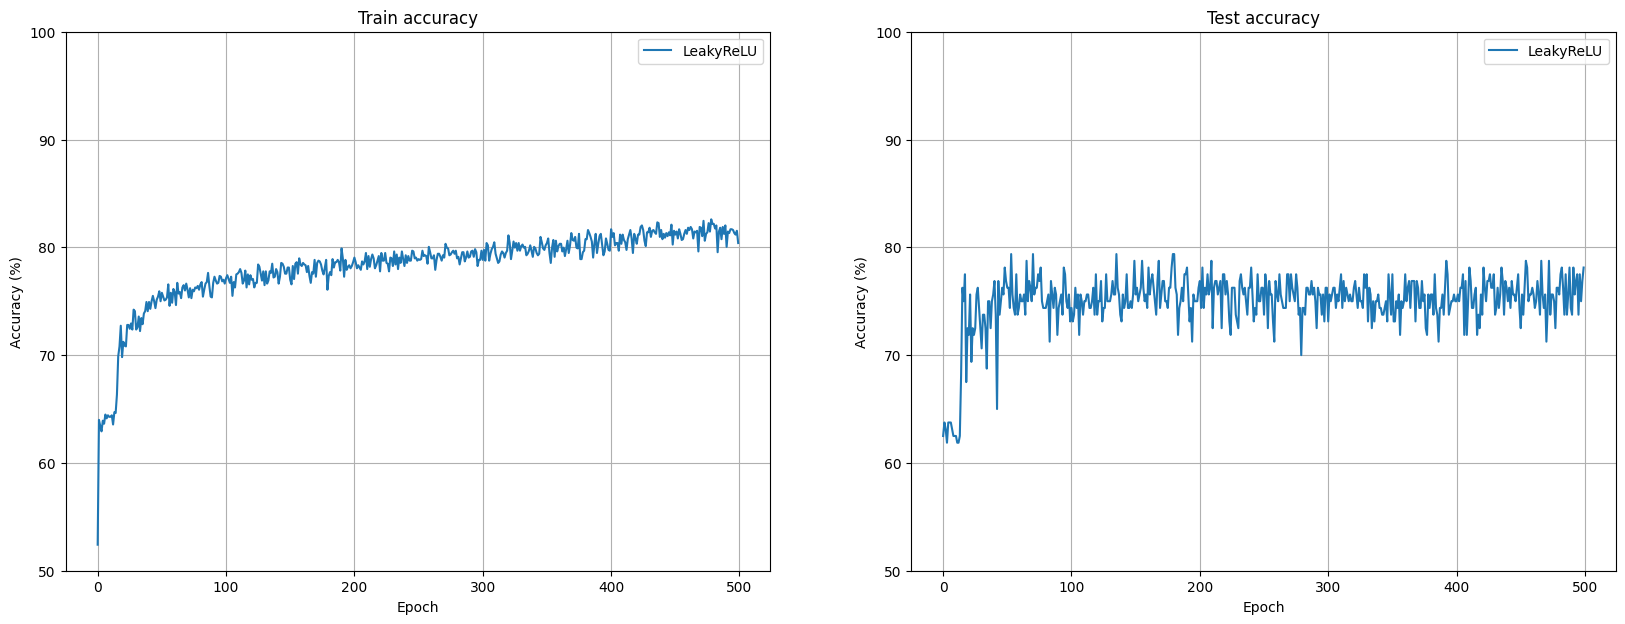

In [32]:
train_loader, test_loader = get_train_test_dataloaders(data, 5)
train_model_and_plot_results(train_loader, test_loader)

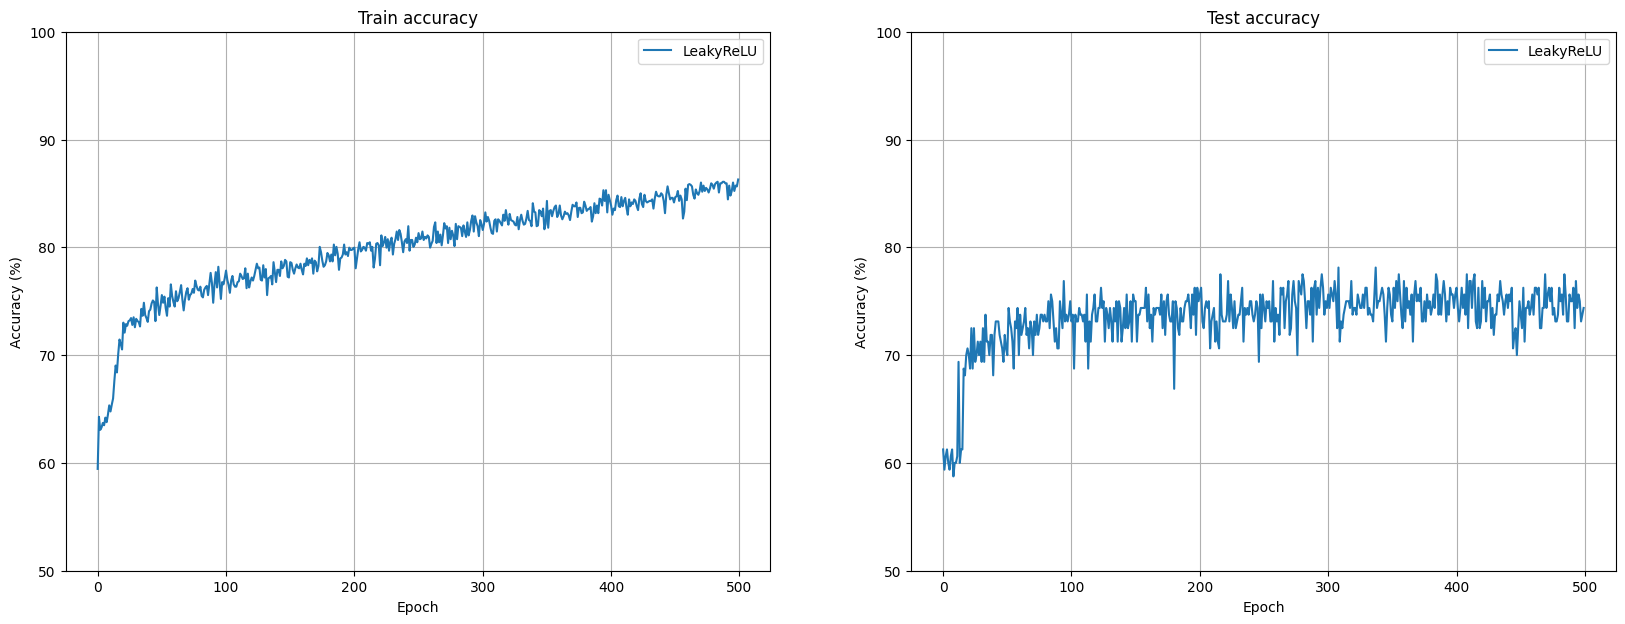

In [33]:
train_loader, test_loader = get_train_test_dataloaders(data, 5.5)
train_model_and_plot_results(train_loader, test_loader)

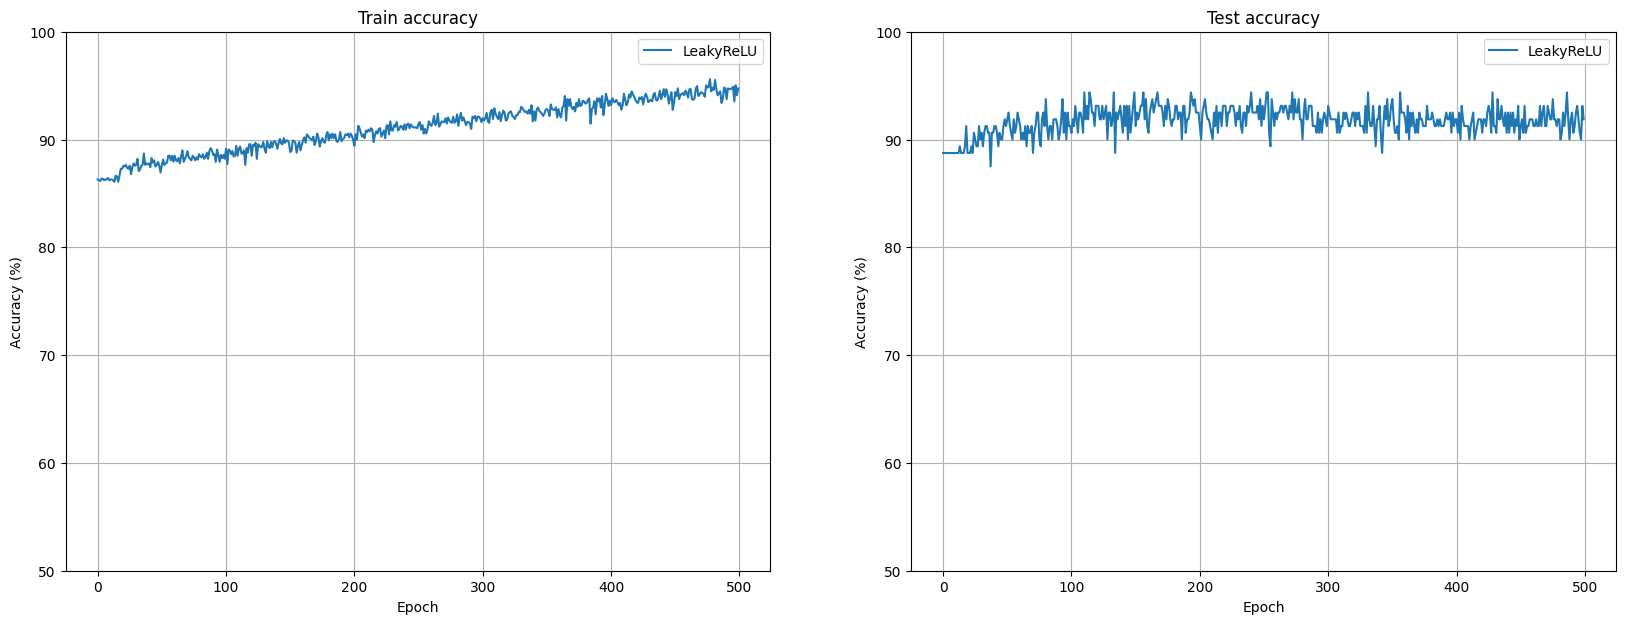

In [34]:
train_loader, test_loader = get_train_test_dataloaders(data, 6.5)
train_model_and_plot_results(train_loader, test_loader)

## Data oversampling in MNIST

In [35]:
data_full = np.loadtxt(open("./mnist_train_small.csv", 'rb'), delimiter=',')

def create_dataset(n, double_the_data=False):
    labels_local = data_full[:n, 0]
    data_local = data_full[:n , 1:]
    data_norm = data_local / np.max(data_local)
    
    # if double_the_data:
    #     data_norm = np.concatenate((data_norm, data_norm), axis=0)
    #     labels_local = np.concatenate((labels_local, labels_local), axis=0)
        
    data_t_local = torch.tensor(data_norm).float()
    labels_t_local = torch.tensor(labels_local).long()
    train_data_local, test_data_local, train_labels_local, test_labels_local = train_test_split(data_t_local, labels_t_local, train_size=.9)
    
    if double_the_data:
        train_data_local = torch.cat((train_data_local, train_data_local), axis=0)
        train_labels_local = torch.cat((train_labels_local, train_labels_local), axis=0)
    
    train_data_local = TensorDataset(train_data_local, train_labels_local)
    test_data_local = TensorDataset(test_data_local, test_labels_local)
    
    batch_size_local = 20
    train_loader_local = DataLoader(train_data_local, batch_size=batch_size_local, shuffle=True, drop_last=True)
    test_loader_local = DataLoader(test_data_local, batch_size=test_data_local.tensors[0].shape[0])
    
    return train_loader_local, test_loader_local

In [36]:
r, t = create_dataset(200, False)

print(r.dataset.tensors[0].shape)
print(t.dataset.tensors[0].shape)

r, t = create_dataset(200, True)

print(r.dataset.tensors[0].shape)
print(t.dataset.tensors[0].shape)

torch.Size([180, 784])
torch.Size([20, 784])
torch.Size([360, 784])
torch.Size([20, 784])


In [37]:
def create_mnist_model():
    class MnistNet(nn.Module):
        def __init__(self):
            super().__init__()
            
            self.input = nn.Linear(784, 64)
            self.fc1 = nn.Linear(64, 32)
            self.fc2 = nn.Linear(32, 32)
            self.output = nn.Linear(32, 10)
            
        def forward(self, x):
            x = F.relu(self.input(x))
            x = F.relu(self.fc1(x))
            x = F.relu(self.fc2(x))
            
            return self.output(x)
            
    net_local = MnistNet()
    loss_fun_local = nn.CrossEntropyLoss()
    opt_local = torch.optim.SGD(net_local.parameters(), lr=.01)
    
    return net_local, loss_fun_local, opt_local

In [38]:
def train_model(model_param, loss_fun_param, optimizer_param, epochs_param=50):
    train_accuracies_local = []
    test_accuracies_local = []
    losses_local = []
     
    for epoch in range(epochs_param):
        batch_accuracies = []
        batch_losses = []
         
        model_param.train()
         
        for X_local, y_local in train_loader:
            y_pred = model_param(X_local)
            loss = loss_fun_param(y_pred, y_local)
               
            optimizer_param.zero_grad()
            loss.backward()
            optimizer_param.step()
               
            correct_predictions = (torch.argmax(y_pred, axis=1) == y_local).float()
             
            batch_accuracies.append(100 * torch.mean(correct_predictions).item())
            batch_losses.append(loss.item())

        train_accuracies_local.append(np.mean(batch_accuracies))
        losses_local.append(np.mean(batch_losses))
    
        model_param.eval()
          
        X_local, y_local = next(iter(test_loader))
          
        with torch.no_grad():
            y_pred = model_param(X_local)
          
        correct_predictions = (torch.argmax(y_pred, axis=1) == y_local).float()
          
        test_accuracies_local.append(100 * torch.mean(correct_predictions).item())
     
    return train_accuracies_local, test_accuracies_local, losses_local

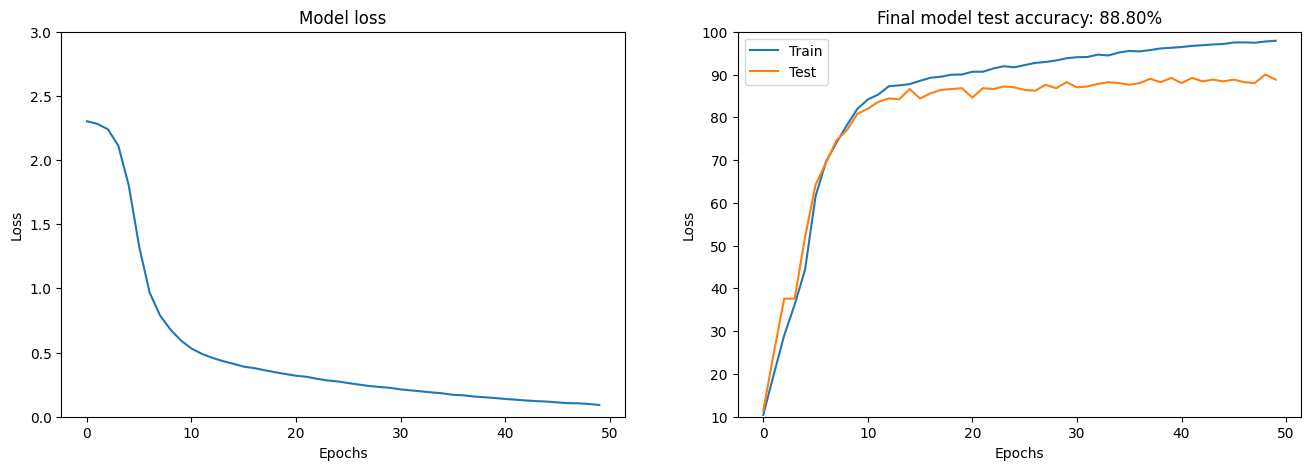

In [39]:
train_loader, test_loader = create_dataset(5000)
net, loss_fun, opt = create_mnist_model()
train_acc, test_acc, losses = train_model(net, loss_fun, opt)

_, ax = plt.subplots(1, 2, figsize=(16, 5))

ax[0].plot(losses)
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].set_ylim([0, 3])
ax[0].set_title("Model loss")

ax[1].plot(train_acc, label='Train')
ax[1].plot(test_acc, label='Test')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Loss')
ax[1].set_ylim([10, 100])
ax[1].set_title(f"Final model test accuracy: {test_acc[-1]:.2f}%")
ax[1].legend()

plt.show()

In [40]:
sample_sizes = np.arange(500, 4001, 500)
results_single = np.zeros((len(sample_sizes), 3))
results_double = np.zeros((len(sample_sizes), 3))

for idx, sample_size in enumerate(sample_sizes):
    train_loader, test_loader = create_dataset(sample_size, False)
    net, loss_fun, opt = create_mnist_model()
    train_acc, test_acc, losses = train_model(net, loss_fun, opt)
    
    results_single[idx, 0] = np.mean(train_acc[-5:])
    results_single[idx, 1] = np.mean(test_acc[-5:])
    results_single[idx, 2] = np.mean(losses[-5:])
    
    train_loader, test_loader = create_dataset(sample_size, True)
    net, loss_fun, opt = create_mnist_model()
    train_acc, test_acc, losses = train_model(net, loss_fun, opt)
    
    results_double[idx, 0] = np.mean(train_acc[-5:])
    results_double[idx, 1] = np.mean(test_acc[-5:])
    results_double[idx, 2] = np.mean(losses[-5:])

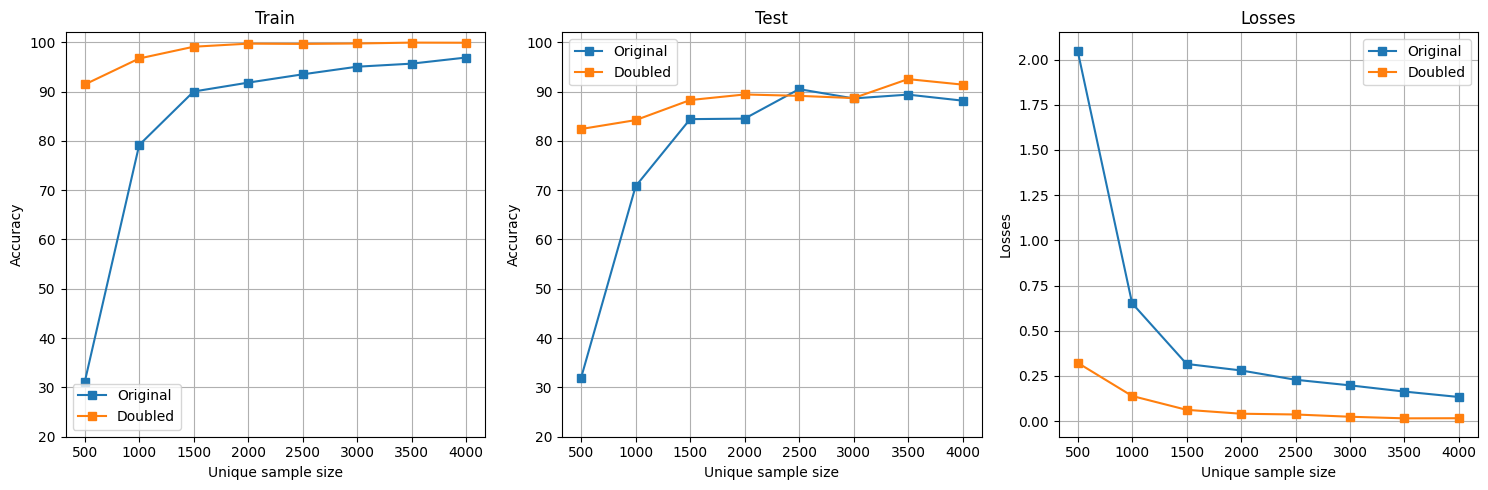

In [41]:
_, ax = plt.subplots(1, 3, figsize=(15, 5))

titles = ['Train', 'Test', 'Losses']
y_ax_labels = ['Accuracy', 'Accuracy', 'Losses']

for i in range(3):
    ax[i].plot(sample_sizes, results_single[:, i], 's-', label='Original')
    ax[i].plot(sample_sizes, results_double[:, i], 's-', label='Doubled')
    ax[i].set_ylabel(y_ax_labels[i])
    ax[i].set_title(titles[i])
    ax[i].legend()
    ax[i].set_xlabel("Unique sample size")
    ax[i].grid('on')
    
    if i < 2:
        ax[i].set_ylim([20, 102])
        
plt.tight_layout()
plt.show()

## Data noise augmentation (with devset+test)

In [42]:
data_full = np.loadtxt(open("./mnist_train_small.csv", 'rb'), delimiter=',')
data_full[:, 1:] = data_full[:, 1:] / np.max(data_full)

def create_dataset(n, double_the_data=False):
    data_local = data_full[:n, 1:]
    labels_local = data_full[:n, 0]
    
    if double_the_data:
        data_norm = data_local + np.random.random_sample(data_local.shape) / 2
        data_local = np.concatenate((data_local, data_norm), axis=0)
        labels_local = np.concatenate((labels_local, labels_local), axis=0)
        
    data_t_local = torch.tensor(data_local).float()
    labels_t_local = torch.tensor(labels_local).long()
    train_data_local, val_data_local, train_labels_local, val_labels_local = train_test_split(data_t_local, labels_t_local, train_size=.9)
    
    # if double_the_data:
    #     train_data_local = torch.cat((train_data_local, train_data_local), axis=0)
    #     train_labels_local = torch.cat((train_labels_local, train_labels_local), axis=0)
    
    train_data_local = TensorDataset(train_data_local, train_labels_local)
    val_data_local = TensorDataset(val_data_local, val_labels_local)
    
    batch_size_local = 20
    train_loader_local = DataLoader(train_data_local, batch_size=batch_size_local, shuffle=True, drop_last=True)
    val_loader_local = DataLoader(val_data_local, batch_size=val_data_local.tensors[0].shape[0])
    
    test_data_local = torch.tensor(data_full[n:, 1:]).float()
    test_labels_local = torch.tensor(data_full[n:, 0]).long()
    
    return train_loader_local, val_loader_local, (test_data_local, test_labels_local)

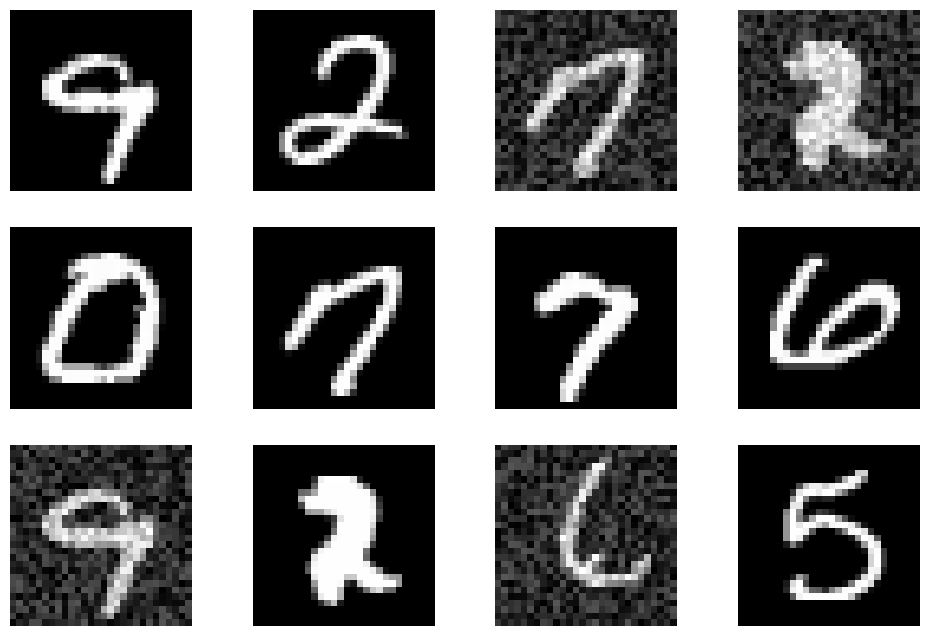

In [43]:
train_loader, val_loader, test_dataset = create_dataset(12, True)
img = train_loader.dataset.tensors[0].detach()

_, ax = plt.subplots(3, 4, figsize=(12, 8))

for i, ax in enumerate(ax.flatten()):
    ax.imshow(np.reshape(img[i, :], (28, 28)), cmap='gray')
    ax.axis('off')
    
plt.show()

In [44]:
sample_sizes = np.arange(500, 4001, 500)
results_single = np.zeros((len(sample_sizes), 3))
results_double = np.zeros((len(sample_sizes), 3))

for idx, sample_size in enumerate(sample_sizes):
    train_loader, val_loader, test_dataset = create_dataset(sample_size, False)
    net, loss_fun, opt = create_mnist_model()
    train_acc, val_acc, losses = train_model(net, loss_fun, opt)
    
    results_single[idx, 0] = np.mean(train_acc[-5:])
    results_single[idx, 1] = np.mean(val_acc[-5:])
    results_single[idx, 2] = np.mean(losses[-5:])
    
    train_loader, val_loader, test_dataset = create_dataset(sample_size, True)
    net, loss_fun, opt = create_mnist_model()
    train_acc, val_acc, losses = train_model(net, loss_fun, opt)
    
    results_double[idx, 0] = np.mean(train_acc[-5:])
    results_double[idx, 1] = np.mean(val_acc[-5:])
    results_double[idx, 2] = np.mean(losses[-5:])

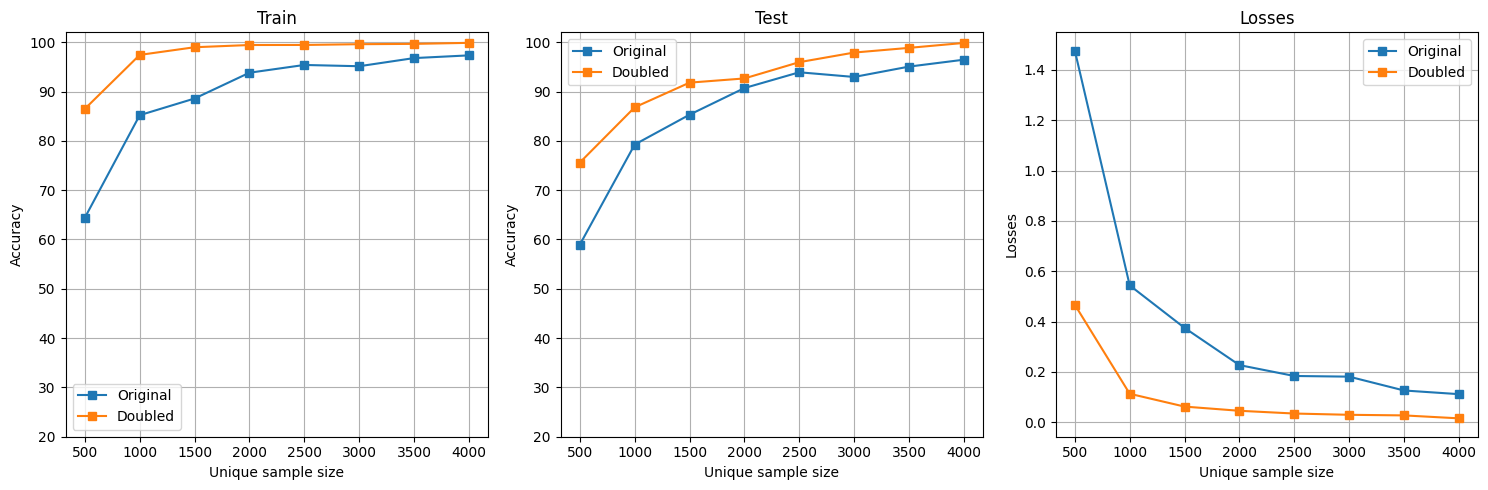

In [45]:
_, ax = plt.subplots(1, 3, figsize=(15, 5))

titles = ['Train', 'Test', 'Losses']
y_ax_labels = ['Accuracy', 'Accuracy', 'Losses']

for i in range(3):
    ax[i].plot(sample_sizes, results_single[:, i], 's-', label='Original')
    ax[i].plot(sample_sizes, results_double[:, i], 's-', label='Doubled')
    ax[i].set_ylabel(y_ax_labels[i])
    ax[i].set_title(titles[i])
    ax[i].legend()
    ax[i].set_xlabel("Unique sample size")
    ax[i].grid('on')
    
    if i < 2:
        ax[i].set_ylim([20, 102])
        
plt.tight_layout()
plt.show()

In [46]:
sample_size = 500

train_loader, val_loader, test_dataset = create_dataset(sample_size, False)
net_o, loss_fun, opt = create_mnist_model()
train_acc_o, val_acc_o, losses_o = train_model(net_o, loss_fun, opt)

train_loader, val_loader, test_dataset = create_dataset(sample_size, True)
net_a, loss_fun, opt = create_mnist_model()
train_acc_a, val_acc_a, losses_a = train_model(net_a, loss_fun, opt)

In [47]:
X, y = test_dataset

y_pred = net_o(X)
test_o = 100 * torch.mean((torch.argmax(y_pred, axis=1) == y).float())

y_pred = net_a(X)
test_a = 100 * torch.mean((torch.argmax(y_pred, axis=1) == y).float())

print(f"ORIGINAL MODEL (N={sample_size}):\n  Train: {train_acc_o[-1]:.2f}%, val: {val_acc_o[-1]:.2f}%, test: {test_o:.2f}%")
print(f"AUGMENTED MODEL (N={sample_size}):\n  Train: {train_acc_a[-1]:.2f}%, val: {val_acc_a[-1]:.2f}%, test: {test_a:.2f}%")

ORIGINAL MODEL (N=500):
  Train: 48.64%, val: 40.00%, test: 42.17%
AUGMENTED MODEL (N=500):
  Train: 93.89%, val: 81.00%, test: 81.51%


## Data feature augmentation

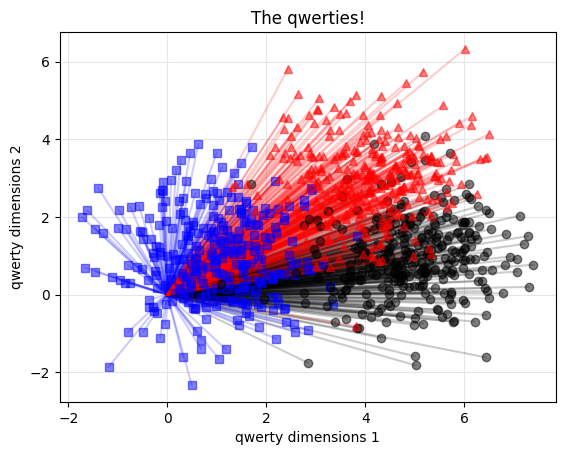

In [48]:
n_per_clust = 300
blur = 1

A = [1, 1]
B = [5, 1]
C = [4, 3]

a = [A[0] + np.random.randn(n_per_clust) * blur, A[1] + np.random.randn(n_per_clust) * blur]
b = [B[0] + np.random.randn(n_per_clust) * blur, B[1] + np.random.randn(n_per_clust) * blur]
c = [C[0] + np.random.randn(n_per_clust) * blur, C[1] + np.random.randn(n_per_clust) * blur]

data_np = np.hstack((a, b, c)).T
labels_np = np.hstack((np.zeros(n_per_clust), np.ones(n_per_clust), 1 + np.ones(n_per_clust)))

data = torch.tensor(data_np).float()
labels = torch.tensor(labels_np).long()

plt.figure()

color = 'bkr'

for i_local in range(len(data)):
    plt.plot([0, data[i_local, 0]], [0, data[i_local, 1]], color=color[labels[i_local]], alpha=.2)

plt.plot(data[np.where(labels==0)[0], 0], data[np.where(labels==0)[0], 1], 'bs', alpha=.5)
plt.plot(data[np.where(labels==1)[0], 0], data[np.where(labels==1)[0], 1], 'ko', alpha=.5)
plt.plot(data[np.where(labels==2)[0], 0], data[np.where(labels==2)[0], 1], 'r^', alpha=.5)
plt.grid(color=[.9, .9, .9])
plt.title("The qwerties!")
plt.xlabel("qwerty dimensions 1")
plt.ylabel("qwerty dimensions 2")
plt.show()

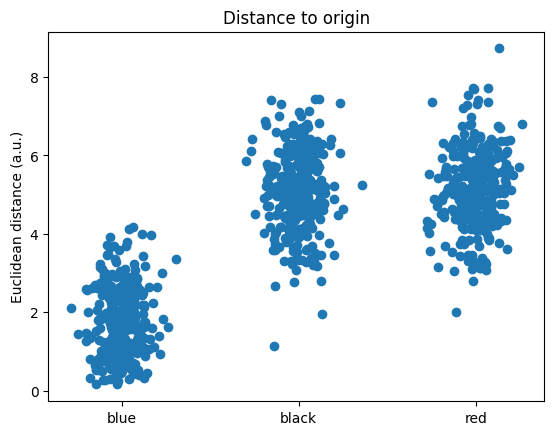

In [49]:
dist_to_orig = torch.sqrt(data[:, 0] ** 2 + data[:, 1] ** 2)

plt.plot(labels + torch.randn(900) / 10, dist_to_orig, 'o')
plt.xticks([0, 1, 2], labels=['blue', 'black', 'red'])
plt.ylabel("Euclidean distance (a.u.)")
plt.title("Distance to origin")
plt.show()

In [50]:
data_aug = torch.cat((data, dist_to_orig.view(len(data), 1)), axis=1)

print(data.shape)
print(data_aug.shape)
print(' ')
print(data_aug)

torch.Size([900, 2])
torch.Size([900, 3])
 
tensor([[0.3073, 2.4962, 2.5150],
        [1.7539, 0.8089, 1.9314],
        [1.2772, 2.5087, 2.8152],
        ...,
        [4.4590, 1.9157, 4.8531],
        [6.5095, 4.1410, 7.7150],
        [5.5042, 4.0062, 6.8077]])


In [51]:
train_data, test_data, train_labels, test_labels = train_test_split(data_aug, labels, test_size=.1)

train_data = TensorDataset(train_data, train_labels)
test_data = TensorDataset(test_data, test_labels)

batch_size = 16
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, drop_last=True)
test_loader = DataLoader(test_data, batch_size=test_data.tensors[0].shape[0])

In [52]:
def create_qwerty_model(use_extra_feature=False):
    class QwertyNet(nn.Module):
        def __init__(self):
            super().__init__()
            
            if use_extra_feature:
                self.input = nn.Linear(3, 8)
            else:
                self.input = nn.Linear(2, 8)
                
            self.fc1 = nn.Linear(8, 8)
            self.output = nn.Linear(8, 3)
            
        def forward(self, x):
            if not use_extra_feature:
                x = x[:, :2]
            
            x = F.relu(self.input(x))
            x = F.relu(self.fc1(x))
            
            return self.output(x)
        
    net_local = QwertyNet()
    loss_fun_local = nn.CrossEntropyLoss()
    opt_local = torch.optim.SGD(net_local.parameters(), lr=.001)
    
    return net_local, loss_fun_local, opt_local

In [53]:
print("Using augmented feature:")

net = create_qwerty_model(True)[0]
net(next(iter(train_loader))[0])

Using augmented feature:


tensor([[ 0.3736,  0.0375, -0.4332],
        [ 0.2419,  0.0233, -0.3116],
        [ 0.3191,  0.0355, -0.3804],
        [ 0.3843,  0.0446, -0.4390],
        [ 0.4221,  0.0488, -0.4742],
        [ 0.3585,  0.0346, -0.4201],
        [ 0.3050,  0.0242, -0.3735],
        [ 0.3489,  0.0350, -0.4102],
        [ 0.3780,  0.0383, -0.4371],
        [ 0.3519,  0.0333, -0.4143],
        [ 0.4354,  0.0499, -0.4867],
        [ 0.3884,  0.0290, -0.4329],
        [ 0.2544,  0.0229, -0.3242],
        [ 0.3731,  0.0431, -0.4292],
        [ 0.3879,  0.0447, -0.4429],
        [ 0.2600,  0.0274, -0.3269]], grad_fn=<AddmmBackward0>)

In [54]:
print("Not using augmented feature:")

net = create_qwerty_model(False)[0]
net(next(iter(train_loader))[0])

Not using augmented feature:


tensor([[-0.4217, -0.9774, -0.7878],
        [-0.4001, -0.9227, -0.7218],
        [-0.3990, -0.9083, -0.7505],
        [-0.3472, -0.7489, -0.6579],
        [-0.1844, -0.2206, -0.4126],
        [-0.4140, -0.9671, -0.7723],
        [-0.2334, -0.2811, -0.3058],
        [-0.4187, -0.9680, -0.7816],
        [-0.1958, -0.2512, -0.4307],
        [-0.3373, -0.7227, -0.6159],
        [-0.1700, -0.1687, -0.3143],
        [-0.1803, -0.1903, -0.2996],
        [-0.4276, -1.0150, -0.7756],
        [-0.3544, -0.7722, -0.6764],
        [-0.3437, -0.7393, -0.6572],
        [-0.3453, -0.7573, -0.6541]], grad_fn=<AddmmBackward0>)

In [55]:
def train_model(use_extra_feature=False):
    num_epochs = 200
    net_local, loss_fun_local, opt_local = create_qwerty_model(use_extra_feature)
    losses_local = torch.zeros(num_epochs)
    train_acc_local = []
    test_acc_local = []
    
    for epoch_i in range(num_epochs):
        batch_acc = []
        batch_loss = []
        
        for X_local, y_local in train_loader:
            y_pred = net_local(X_local)
            loss = loss_fun_local(y_pred, y_local)
            
            opt_local.zero_grad()
            loss.backward()
            opt_local.step()
            
            batch_loss.append(loss.item())
            
            matches = torch.argmax(y_pred, axis=1) == y_local
            matches_numeric = matches.float()
            accuracy_per = 100 * torch.mean(matches_numeric)
            batch_acc.append(accuracy_per)
            
        train_acc_local.append(np.mean(batch_acc))
        
        losses_local[epoch_i] = np.mean(batch_loss)
        
        X, y = next(iter(test_loader))
        
        with torch.no_grad():
            y_pred = net_local(X)
            
        test_acc_local.append(100 * torch.mean((torch.argmax(y_pred, axis=1) == y).float()))
        
    return train_acc_local, test_acc_local, losses_local, net_local

In [56]:
def plot_results():
    y_pred_local = net(data_aug)
    preds = torch.argmax(y_pred_local, axis=1)
    accuracy = (preds == labels).float()
    accuracy_by_group = np.zeros(3)
    
    for i_local in range(3):
        accuracy_by_group[i_local] = 100 * torch.mean(accuracy[labels == i_local])
        
    _, ax_local = plt.subplots(2, 2, figsize=(10, 6))

    ax_local[0, 0].plot(losses.detach())
    ax_local[0, 0].set_ylabel('Loss')
    ax_local[0, 0].set_xlabel('Epoch')
    ax_local[0, 0].set_title('Losses')

    ax_local[0, 1].plot(train_acc, label='Train')
    ax_local[0, 1].plot(test_acc, label='Test')
    ax_local[0, 1].set_ylabel("Accuracy (%)")
    ax_local[0, 1].set_xlabel('Epoch')
    ax_local[0, 1].set_title('Accuracy')
    ax_local[0, 1].legend()

    ax_local[1, 0].bar(range(3), accuracy_by_group)
    ax_local[1, 0].set_ylim([np.min(accuracy_by_group) - 5, np.max(accuracy_by_group) + 5])
    ax_local[1, 0].set_xticks([0, 1, 2])
    ax_local[1, 0].set_xlabel('Group')
    ax_local[1, 0].set_ylabel("Accuracy (%)")
    ax_local[1, 0].set_title("Accuracy by group")

    color_shapes = ['bs','ko','g^']
    
    for i_local in range(3):
        ax_local[1, 1].plot(data_aug[labels == i_local, 0], data_aug[labels == i_local, 1], color_shapes[i_local], alpha=.3, label=f"Group {i_local}")
        
        idx_err = (accuracy == 0) & (labels == i_local)
        ax_local[1, 1].plot(data_aug[idx_err, 0], data_aug[idx_err, 1], 'rx')
    
    ax_local[1, 1].set_title("All groups")
    ax_local[1, 1].set_xlabel("qwerty dimension 1")
    ax_local[1, 1].set_ylabel("qwerty dimension 2")
    ax_local[1, 1].legend()
    
    plt.tight_layout()
    plt.show()

Final accuracy: 88.89%


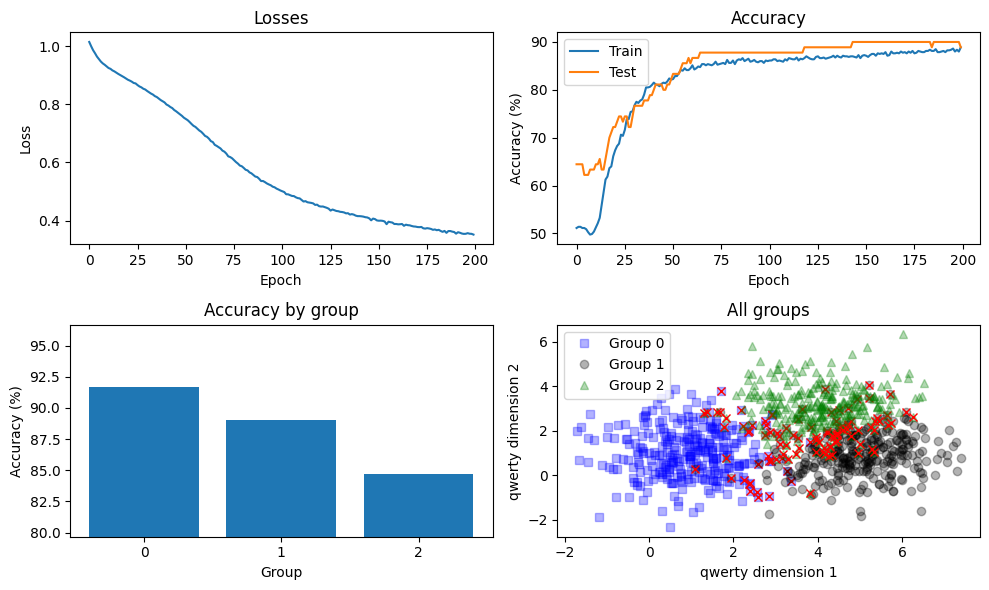

In [57]:
train_acc, test_acc, losses, net = train_model(False)

print("Final accuracy: %.2f%%" %test_acc[-1].item())

plot_results()

Final accuracy: 88.89%


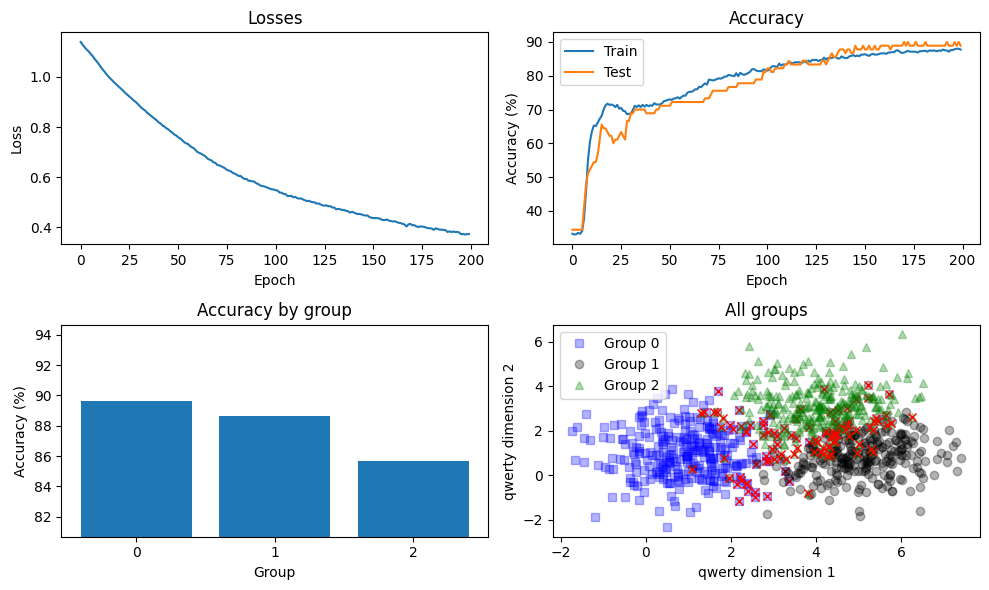

In [58]:
train_acc, test_acc, losses, net = train_model(True)

print("Final accuracy: %.2f%%" %test_acc[-1].item())

plot_results()

In [59]:
final_acc_2 = np.zeros(10)
final_acc_3 = np.zeros(10)

for i in range(10):
  final_acc_2[i] = train_model(False)[1][-1]
  final_acc_3[i] = train_model(True)[1][-1]

print(np.round(np.vstack((final_acc_2, final_acc_3)).T, 2))

t, p = stats.ttest_ind(final_acc_2, final_acc_3)

print()
print("t=%.2f, p=%.2f" %(t, p))

[[88.89 87.78]
 [77.78 88.89]
 [88.89 87.78]
 [87.78 78.89]
 [90.   88.89]
 [88.89 90.  ]
 [88.89 90.  ]
 [90.   88.89]
 [90.   86.67]
 [86.67 88.89]]

t=0.07, p=0.94


## Save and load trained models

In [60]:
torch.save(net.state_dict(), 'trained_model.pt')

In [61]:
model_1, _, _ = create_qwerty_model(True)
model_2, _, _ = create_qwerty_model(True)

model_1.load_state_dict(torch.load('trained_model.pt'))

<All keys matched successfully>

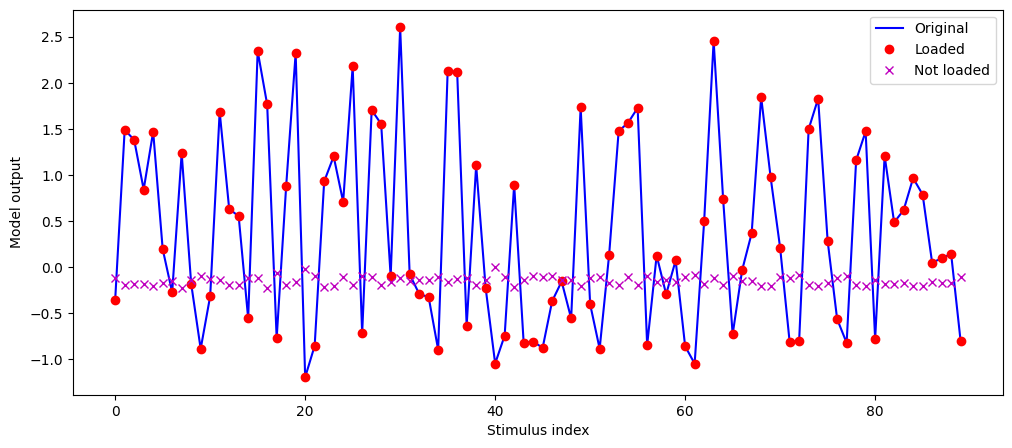

In [62]:
X, y = next(iter(test_loader))

y_pred_net = net(X)
y_pred_model_1 = model_1(X)
y_pred_model_2 = model_2(X)

fig = plt.figure(figsize=(12, 5))
plt.plot(y_pred_net[:, 2].detach(), 'b', label='Original')
plt.plot(y_pred_model_1[:, 2].detach(), 'ro', label='Loaded')
plt.plot(y_pred_model_2[:, 2].detach(), 'mx', label="Not loaded")
plt.legend()
plt.xlabel("Stimulus index")
plt.ylabel("Model output")
plt.show()

## Save the best-performing model

In [63]:
the_best = [0, 0]

for i in range(10):
    accuracy = np.random.rand()
    
    if accuracy > the_best[0]:
        the_best = [accuracy, i]
        
print(f'Highest "accuracy" was {100 * the_best[0]:.2f}% in run {the_best[1] + 1}.')

Highest "accuracy" was 97.54% in run 10.


In [64]:
partitions = [3 * n_per_clust - 400, 200, 200]

train_data, val_test_data, train_labels, val_test_labels = train_test_split(data, labels, train_size=partitions[0])
val_data, test_data, val_labels, test_labels = train_test_split(val_test_data, val_test_labels, train_size=partitions[1])

print(f"Total data size: {str(data.shape)}")
print(f"Training data size: {str(train_data.shape)}")
print(f"Validation data size: {str(val_data.shape)}")
print(f"Test data size: {str(test_data.shape)}")

Total data size: torch.Size([900, 2])
Training data size: torch.Size([500, 2])
Validation data size: torch.Size([200, 2])
Test data size: torch.Size([200, 2])


In [65]:
train_data = TensorDataset(train_data, train_labels)
val_data = TensorDataset(val_data, val_labels)
test_data = TensorDataset(test_data, test_labels)

batch_size = 30
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, drop_last=True)
val_loader = DataLoader(val_data, batch_size=val_data.tensors[0].shape[0])
test_loader = DataLoader(test_data, batch_size=test_data.tensors[0].shape[0])

In [66]:
def create_qwerty_model():
    class QwertyNet(nn.Module):
        def __init__(self):
            super().__init__()

            self.input = nn.Linear(2, 8)
            self.fc1 = nn.Linear(8, 8)
            self.output = nn.Linear(8, 3)
            
        def forward(self, x):
            x = F.relu(self.input(x))
            x = F.relu(self.fc1(x))
            
            return self.output(x)
        
    net_local = QwertyNet()
    loss_fun_local = nn.CrossEntropyLoss()
    opt_local = torch.optim.SGD(net_local.parameters(), lr=.01)
    
    return net_local, loss_fun_local, opt_local

In [67]:
def train_model():
    the_best_model = { 'accuracy': 0, 'net': None }
    num_epochs = 100
    net_local, loss_fun_local, opt_local = create_qwerty_model()
    losses_local = torch.zeros(num_epochs)
    train_acc_local = []
    val_acc_local = []
    
    for epoch_i in range(num_epochs):
        net_local.train()
        
        batch_acc = []
        batch_loss = []
        
        for X_local, y_local in train_loader:
            y_pred = net_local(X_local)
            loss = loss_fun_local(y_pred, y_local)
            
            opt_local.zero_grad()
            loss.backward()
            opt_local.step()
            
            batch_loss.append(loss.item())
            
            matches = torch.argmax(y_pred, axis=1) == y_local
            matches_numeric = matches.float()
            accuracy_per = 100 * torch.mean(matches_numeric)
            batch_acc.append(accuracy_per)
            
        train_acc_local.append(np.mean(batch_acc))
        
        losses_local[epoch_i] = np.mean(batch_loss)
        
        net_local.eval()

        X, y = next(iter(val_loader))
        
        with torch.no_grad():
            y_pred = net_local(X)
            
        val_acc_local.append(100 * torch.mean((torch.argmax(y_pred, axis=1) == y).float()))
        
        if val_acc_local[-1] > the_best_model['accuracy']:
            the_best_model['accuracy'] = val_acc_local[-1].item()
            the_best_model['net'] = copy.deepcopy(net_local.state_dict())
        
    return train_acc_local, val_acc_local, losses_local, the_best_model

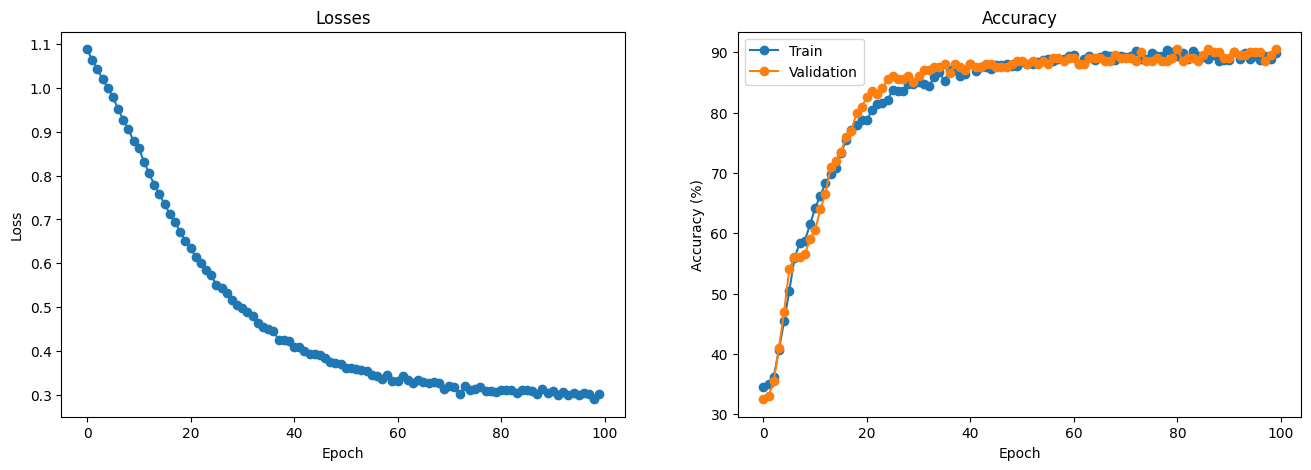

In [68]:
train_acc, val_acc, losses, the_best_model = train_model()
_, ax = plt.subplots(1, 2, figsize=(16, 5))

ax[0].plot(losses.detach(), 'o-')
ax[0].set_ylabel('Loss')
ax[0].set_xlabel('Epoch')
ax[0].set_title('Losses')
ax[1].plot(train_acc, 'o-', label='Train')
ax[1].plot(val_acc, 'o-', label='Validation')
ax[1].set_ylabel("Accuracy (%)")
ax[1].set_xlabel('Epoch')
ax[1].set_title('Accuracy')
ax[1].legend()
plt.show()

In [69]:
the_best_model

{'accuracy': 90.5,
 'net': OrderedDict([('input.weight',
               tensor([[ 0.5728,  0.6653],
                       [-0.2177,  0.5520],
                       [ 0.2087,  0.5867],
                       [ 0.7652, -0.1892],
                       [ 0.3980,  0.4832],
                       [-0.2960,  0.7717],
                       [ 0.1112,  0.7590],
                       [ 0.9841,  0.1140]])),
              ('input.bias',
               tensor([-0.0744, -0.3964,  0.3834,  0.7206,  0.2423,  0.8893, -0.6198, -0.7979])),
              ('fc1.weight',
               tensor([[-0.0030,  0.2674,  0.3454,  0.3149,  0.3236, -0.4497, -0.0231,  0.5227],
                       [-0.3359,  0.0736,  0.4800,  0.4737,  0.0594,  0.7869, -0.2351, -0.5783],
                       [-0.1044, -0.0379,  0.2490,  0.0111, -0.0251,  0.3793, -0.2526, -0.1558],
                       [ 0.4248, -0.0215,  0.2263, -0.2776,  0.3643,  0.3177,  0.3552,  0.2175],
                       [ 0.2336,  0.0069,  0.0074, -

In [70]:
X, y = next(iter(test_loader))
best_net = create_qwerty_model()[0]

best_net.load_state_dict(the_best_model['net'])

<All keys matched successfully>

In [71]:
X, y = next(iter(test_loader))
y_pred = best_net(X)

best_acc = 100 * torch.mean((torch.argmax(y_pred, axis=1) == y).float())
best_acc

tensor(89.)

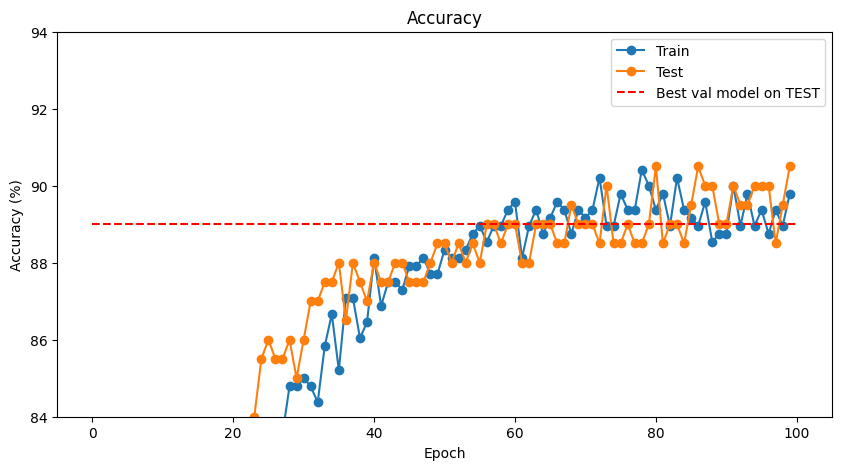

In [72]:
_ = plt.figure(figsize=(10, 5))

plt.plot(train_acc, 'o-', label='Train')
plt.plot(val_acc, 'o-', label='Test')
plt.plot([0, len(val_acc)], [best_acc, best_acc], 'r--', label="Best val model on TEST")
plt.xlabel('Epoch')
plt.ylabel("Accuracy (%)")
plt.title('Accuracy')
plt.ylim([best_acc - 5, best_acc + 5])
plt.legend()
plt.show()